In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import QTable
from matplotlib.patches import Circle

In [2]:
def sort2(data,ra,dec,halfside):
    """Function takes the hst catalog for an entire brick and cuts out all the objects outside of a square postage stamp around a given target's position.
    data is the catalog for an entire brick as the table from a fits file.
    ra and dec are coords of target in degrees
    halfside is half of the square sidelength in arcseconds.
    returns the objects in the postage stamp.
    """

    adjust = (halfside/np.cos(np.deg2rad(dec))) #how wide it needs to be in the ra direction in arcsecs to account for scale factor cos(tar_ra)

    #mark min and max of the box in the x and y directions, in degrees
    xmin = ra-(adjust/3600)
    xmax = ra+(adjust/3600)
    ymin = dec-(halfside/3600)
    ymax = dec+(halfside/3600)

    data = data[data['ra'].value>xmin]
    data = data[data['ra'].value<xmax]
    data = data[data['dec'].value>ymin]
    data = data[data["dec"].value<ymax]
    
    return data
    

In [3]:
#offset_csv = "/Users/meera/Desktop/AST-04 Data/M31_matches_offset_updated.csv"
data = QTable.read("/Users/meera/Desktop/AST-04 Data/M31_Photometry_Complete.fits")

In [4]:
print(data.columns)

<TableColumns names=('ra','dec','f814w','f475w','f336w','f275w')>


In [5]:
ra = data['ra'].value
dec = data['dec'].value

radius_degrees = 0.7 / 3600
ra_star = 10.1114909528529
dec_star = 40.5050777302572

In [6]:
square = sort2(data, ra_star, dec_star, 1)

In [7]:
square.columns


<TableColumns names=('ra','dec','f814w','f475w','f336w','f275w')>

In [12]:
f814w = square["f814w"]
print(np.min(f814w))
print(np.max(f814w))

vmin, vmax = 21, 24
normalized = (f814w - vmin) / (vmax - vmin)
normalized = np.clip(normalized, 0, 1)
sizes = 60 - normalized * (60 - 1)



21.055999755859375
23.844999313354492


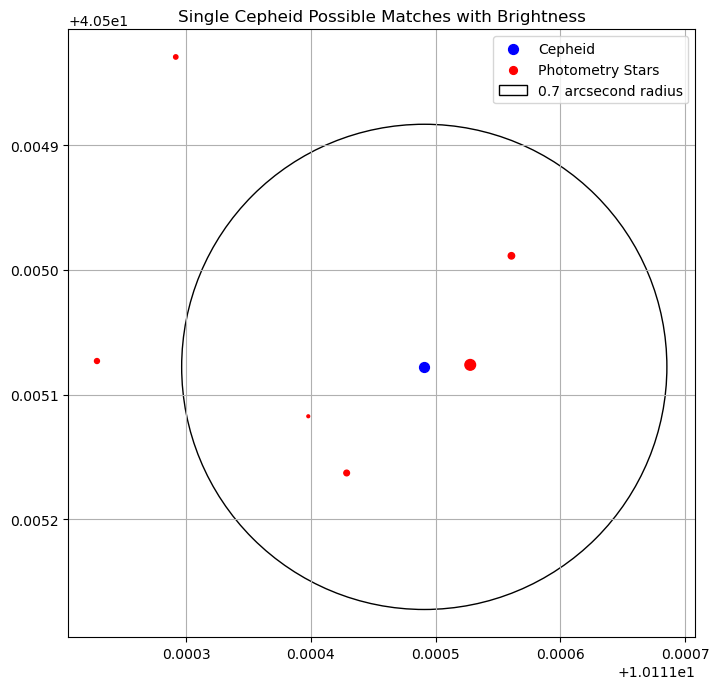

In [15]:
# --- Plot Full CMD from offset file ---
#plot1
plt.figure(figsize=(10, 7))
plt.scatter(ra_star, dec_star, s=50, color='blue', label='Cepheid')
#plt.scatter(square['ra'], square['dec'], s=20, color='red', label='Matched Photometry')
plt.scatter(square['ra'], square['dec'], s=sizes, color='red', label='Photometry Stars')
#plt.scatter(9.967796813767567, 40.51966515588581, s=10, color='purple', label='Match??')
circle = Circle((ra_star, dec_star), radius_degrees, color = "black", fill=False, label = "0.7 arcsecond radius")
plt.gca().set_aspect('equal')
plt.gca().add_patch(circle)

#plt.axhline(24.5, color='red', linestyle='--', label='Magnitude Cut (24.5)')
#plt.xlabel('F475W - F814W')
#plt.ylabel('F814W')
plt.title("Single Cepheid Possible Matches with Brightness")
plt.grid(True)
plt.gca().invert_yaxis()
#plt.xlim(0, 8)
#plt.ylim(24, 17.5)
plt.legend()
plt.tight_layout()
plt.show()